/tmp/ipykernel_2578/1186550858.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dias_ate_consulta'].fillna(df['dias_ate_consulta'].median(), inplace=True)
/tmp/ipykernel_2578/1186550858.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

Dados carregados com sucesso do arquivo .csv!

--- Análise NumPy ---
Média de dias de antecedência nas consultas: 15.66 dias
Desvio Padrão dos dias de antecedência: 9.35 dias


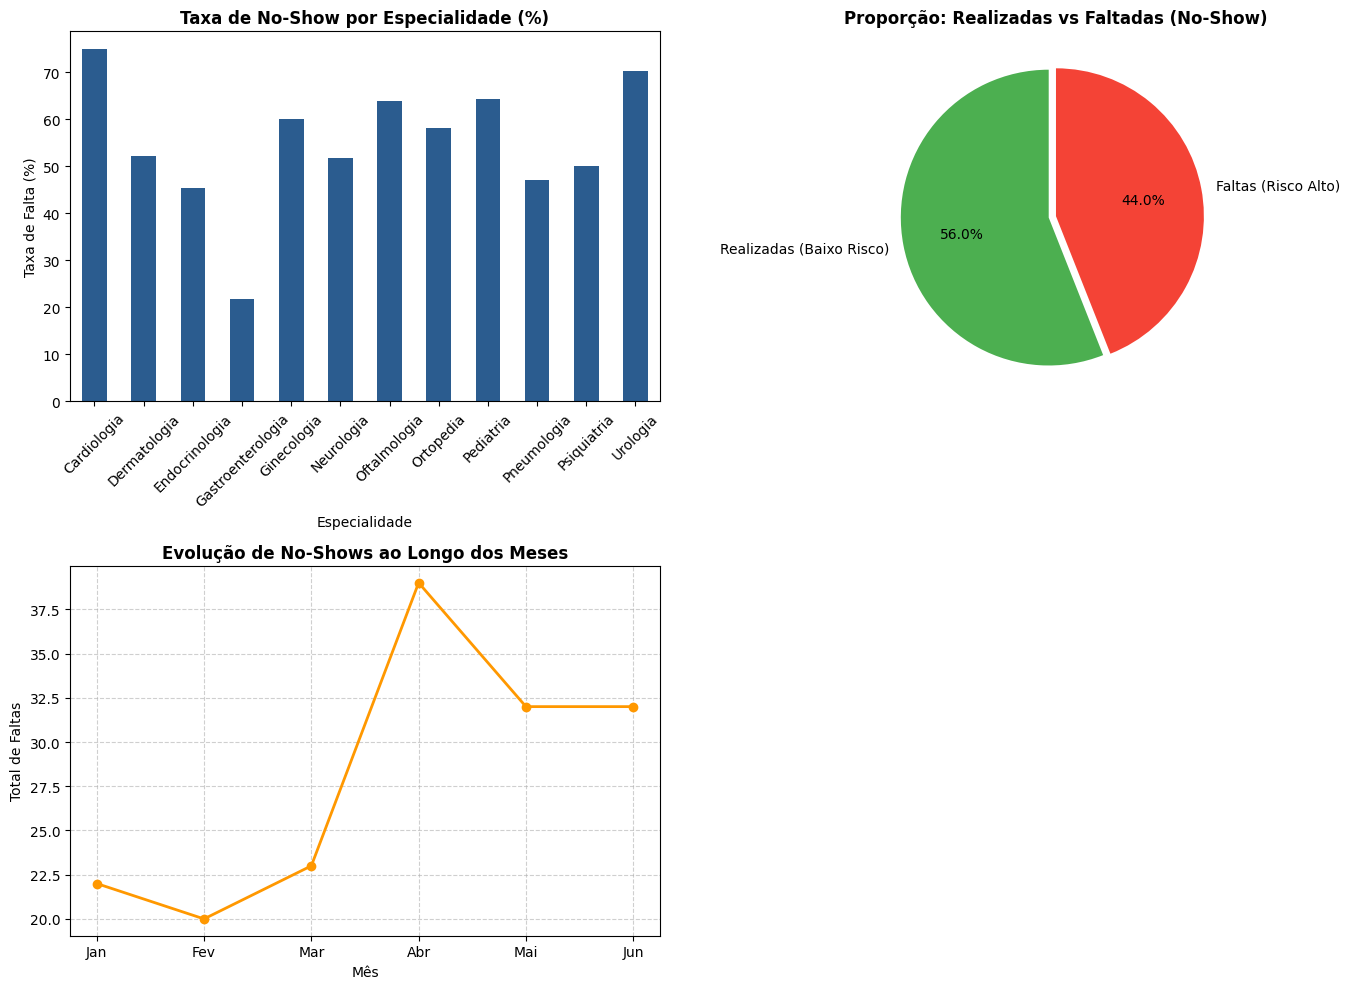


--- Relatório do Modelo de Machine Learning ---
Acurácia do Modelo: 0.75

Relatório de Classificação:
               precision    recall  f1-score   support

 Baixo Risco       0.74      0.65      0.69        26
  Risco Alto       0.76      0.82      0.79        34

    accuracy                           0.75        60
   macro avg       0.75      0.74      0.74        60
weighted avg       0.75      0.75      0.75        60



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Bibliotecas de Machine Learning (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==============================================================================
# ETAPA 1: EXTRAÇÃO, TRANSFORMAÇÃO E TRATAMENTO DE DADOS (ETL)
# ==============================================================================

# Simulação da extração de dados com base na estrutura da base 'clinica_care'
np.random.seed(42)
n_samples = 300

especialidades = ['Pediatria', 'Cardiologia', 'Oftalmologia', 'Dermatologia',
                  'Psiquiatria', 'Pneumologia', 'Ortopedia', 'Ginecologia',
                  'Neurologia', 'Endocrinologia', 'Gastroenterologia', 'Urologia']

# Criação do DataFrame com as features solicitadas no Tema 1
df = pd.DataFrame({
    'id_consulta': range(1, n_samples + 1),
    'especialidade': np.random.choice(especialidades, n_samples),
    'dias_ate_consulta': np.random.randint(0, 31, n_samples),  # Feature: Dias até a consulta
    'historico_faltas': np.random.randint(0, 5, n_samples),    # Feature: Histórico de faltas
    'valor': np.random.choice([180.0, 200.0, 220.0, 250.0, 300.0, 350.0], n_samples),
    'tipo_atendimento': np.random.choice(['Presencial', 'Telemedicina'], n_samples),
    'categoria_consulta': np.random.choice(['Rotina', 'Especialista', 'Retorno', 'Urgencia'], n_samples),
    'mes': np.random.choice(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun'], n_samples)
})

# Regra para gerar o target 'no_show' (1 = Risco Alto / Falta, 0 = Baixo Risco / Realizada)
prob_falta = 0.10 + (df['dias_ate_consulta'] * 0.015) + (df['historico_faltas'] * 0.12)
df['no_show'] = (np.random.rand(n_samples) < prob_falta).astype(int)

# 1.1 Tratamento: Normalização e Gestão de Valores Faltantes
df['dias_ate_consulta'].fillna(df['dias_ate_consulta'].median(), inplace=True)
df['historico_faltas'].fillna(0, inplace=True)

# 1.2 Carga: Salvando e importando o arquivo .csv (Especificações do 2º Print)
csv_file = 'consultas_clinica_care.csv'
df.to_csv(csv_file, index=False)
df_carregado = pd.read_csv(csv_file)
print("Dados carregados com sucesso do arquivo .csv!")

# ==============================================================================
# ETAPA 2: ANÁLISE COM NUMPY (Média e Desvio Padrão)
# ==============================================================================
dias_array = df_carregado['dias_ate_consulta'].to_numpy()
media_dias = np.mean(dias_array)
std_dias = np.std(dias_array)

print(f"\n--- Análise NumPy ---")
print(f"Média de dias de antecedência nas consultas: {media_dias:.2f} dias")
print(f"Desvio Padrão dos dias de antecedência: {std_dias:.2f} dias")

# ==============================================================================
# ETAPA 3: VISUALIZAÇÕES COM MATPLOTLIB
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3.1 Gráfico de Barras: Taxa de no-show por especialidade
taxa_esp = df_carregado.groupby('especialidade')['no_show'].mean() * 100
taxa_esp.plot(kind='bar', color='#2b5c8f', ax=axes[0, 0])
axes[0, 0].set_title('Taxa de No-Show por Especialidade (%)', fontweight='bold')
axes[0, 0].set_ylabel('Taxa de Falta (%)')
axes[0, 0].set_xlabel('Especialidade')
axes[0, 0].tick_params(axis='x', rotation=45)

# 3.2 Gráfico de Pizza: Proporção de consultas realizadas vs faltadas
counts = df_carregado['no_show'].value_counts()
axes[0, 1].pie(counts, labels=['Realizadas (Baixo Risco)', 'Faltas (Risco Alto)'],
               autopct='%1.1f%%', colors=['#4caf50', '#f44336'], startangle=90, explode=(0.05, 0))
axes[0, 1].set_title('Proporção: Realizadas vs Faltadas (No-Show)', fontweight='bold')

# 3.3 Gráfico de Linha: Evolução de no-shows ao longo dos meses
meses_ordem = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun']
evolucao = df_carregado.groupby('mes')['no_show'].sum().reindex(meses_ordem)
axes[1, 0].plot(evolucao.index, evolucao.values, marker='o', color='#ff9800', linewidth=2)
axes[1, 0].set_title('Evolução de No-Shows ao Longo dos Meses', fontweight='bold')
axes[1, 0].set_ylabel('Total de Faltas')
axes[1, 0].set_xlabel('Mês')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Ocultando subplot vago
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()

# ==============================================================================
# ETAPA 4: MODELO DE MACHINE LEARNING (CLASSIFICAÇÃO)
# ==============================================================================
# Definição de Variáveis de Entrada (X) e Alvo (y)
X = df_carregado[['especialidade', 'dias_ate_consulta', 'historico_faltas', 'valor', 'tipo_atendimento', 'categoria_consulta']]
y = df_carregado['no_show']

num_cols = ['dias_ate_consulta', 'historico_faltas', 'valor']
cat_cols = ['especialidade', 'tipo_atendimento', 'categoria_consulta']

# Pré-processamento: Normalização e Codificação Categorizada (One-Hot)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Divisão em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline de Regressão Logística
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Treinamento do Modelo
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)

# Avaliação do Modelo
print("\n--- Relatório do Modelo de Machine Learning ---")
print("Acurácia do Modelo:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred, target_names=['Baixo Risco', 'Risco Alto']))